# Localized curvature experiment

Test whether the high directional curvature $\lambda_{\mathrm{dir}} = \hat g_{\mathrm{pre}}^\top H_{\mathrm{new}}\, \hat g_{\mathrm{pre}}$ at the post-FT
checkpoint is concentrated in the small subset of parameters that encode the fine-tuned skill — i.e.
the **localized region** identified by Panigrahi et al. (2023) "Task-Specific Skill Localization in
Fine-tuned Language Models" (https://github.com/abhishekpanigrahi1996/Skill-Localization-by-grafting).

Pipeline (per concentration $c$):

1. **Phase 1 — Mask optimization.** Find a sparse binary mask $\gamma \in \{0,1\}^d$ such that
   $\theta_{\mathrm{graft}}(\gamma) = \gamma \odot \theta_{\mathrm{ft}} + (1-\gamma)\odot\theta_{\mathrm{pre}}$
   recovers most of the FT performance on the new task. Optimize a continuous relaxation $\gamma=\sigma(s)$
   with AdamW; init from top-$k\%$ magnitude of $\theta_{\mathrm{ft}}-\theta_{\mathrm{pre}}$ as in
   Panigrahi et al.; threshold at the end.
2. **Phase 2 — Curvature decomposition.** At $\theta_{\mathrm{ft}}$, with the binary mask $\gamma$:
   - $\lambda_{\mathrm{dir}}      = \hat g_{\mathrm{pre}}^\top H_{\mathrm{new}}\, \hat g_{\mathrm{pre}}$  (full pre-train direction)
   - $\lambda_{\mathrm{dir}}^{\mathrm{mask}} = (\hat g_{\mathrm{pre}}^{\mathrm{mask}})^\top H_{\mathrm{new}}\, \hat g_{\mathrm{pre}}^{\mathrm{mask}}$,
     using $g_{\mathrm{pre}}^{\mathrm{mask}} = \gamma\odot g_{\mathrm{pre}}$ and renormalizing.
   - $\lambda_{\mathrm{dir}}^{\mathrm{comp}}$ similarly using $(1-\gamma)\odot g_{\mathrm{pre}}$.
   - Magnitudes $\|g_{\mathrm{pre}}^{\mathrm{mask}}\|^2$, $\|g_{\mathrm{pre}}^{\mathrm{comp}}\|^2$ for context.
3. **Phase 3 — Sweep.** Repeat for $c \in \{0.25, 0.5, 0.75, 0.9, 1.0\}$ on Pythia-70M PubMed checkpoints.
4. **Phase 4 — Plot.** $\lambda_{\mathrm{dir}}$, $\lambda_{\mathrm{dir}}^{\mathrm{mask}}$, $\lambda_{\mathrm{dir}}^{\mathrm{comp}}$ vs $c$ on a single log-y plot.

**Sanity note.** $\lambda_{\mathrm{dir}}$ is *not* a literal weighted average of $\lambda_{\mathrm{dir}}^{\mathrm{mask}}$
and $\lambda_{\mathrm{dir}}^{\mathrm{comp}}$; the three are Rayleigh quotients along non-summing directions.
The interesting comparison is their relative magnitudes, especially as $c$ increases.


In [1]:
import os, glob, json, importlib, time
os.chdir(".")

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import torch.utils.data as tud
import matplotlib.pyplot as plt
from pathlib import Path
from transformers import AutoModelForCausalLM, AutoTokenizer

import plot as plot_module
importlib.reload(plot_module)
from config import ExperimentConfig
from data import prepare_datasets, make_eval_loader

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cuda


In [2]:
# ── Utility functions: reuse curvature/gradient routines from cpt_taylor_sweep ──

def get_grad_vector(model, dataset, batch_size=16, num_batches=10):
    """Mean gradient of LM loss over `num_batches` batches, returned as a flat tensor."""
    model.eval(); model.zero_grad()
    loader = make_eval_loader(dataset, batch_size)
    count = 0
    for i, batch in enumerate(loader):
        if i >= num_batches: break
        input_ids = batch.to(device)
        model(input_ids=input_ids, labels=input_ids).loss.backward()
        count += 1
    for p in model.parameters():
        if p.grad is not None:
            p.grad /= max(count, 1)
    grads = [p.grad.detach().flatten() for p in model.parameters() if p.grad is not None]
    model.zero_grad()
    return torch.cat(grads)

def eval_loss(model, dataset, batch_size=16, num_batches=10):
    model.eval()
    loader = make_eval_loader(dataset, batch_size)
    total, count = 0.0, 0
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if i >= num_batches: break
            input_ids = batch.to(device)
            total += model(input_ids=input_ids, labels=input_ids).loss.item()
            count += 1
    return total / max(count, 1)

def get_flat_params(model):
    return torch.cat([p.detach().flatten() for p in model.parameters()])

def set_flat_params(model, flat):
    offset = 0
    for p in model.parameters():
        n = p.numel()
        p.data.copy_(flat[offset:offset+n].view_as(p))
        offset += n

def compute_kappa(model, direction, task_dataset, epsilon=1e-3,
                  batch_size=16, num_batches=10):
    """κ = direction^T H_task direction via central FD-HVP. `direction` must be unit-norm."""
    theta = get_flat_params(model)
    set_flat_params(model, theta + epsilon * direction)
    g_plus = get_grad_vector(model, task_dataset, batch_size, num_batches)
    set_flat_params(model, theta - epsilon * direction)
    g_minus = get_grad_vector(model, task_dataset, batch_size, num_batches)
    set_flat_params(model, theta)
    hvp = (g_plus - g_minus) / (2 * epsilon)
    return torch.dot(direction, hvp).item()

print("Utilities loaded.")


Utilities loaded.


In [3]:
# ── Knobs ────────────────────────────────────────────────────────────
RESULTS_DIR  = "results/20260424_195039_deep_70m_biomedical"

# Concentrations to sweep. The user prompt asked for {0.25, 0.5, 0.75, 0.9, 1.0}.
# Recommended starting point per the prompt: c=1.0 first as proof-of-concept.
BURSTS_TO_RUN = [0.25, 0.50, 0.75, 0.90, 1.00]
# BURSTS_TO_RUN = [1.00]   # uncomment for a quick proof-of-concept

# Phase 1 — mask optimization
SPARSITY_LEVELS = [0.03]                # k ∈ {0.5%, 1%, 5%}; default to a single 3% run
                                        # to keep wall-clock manageable.
MASK_BATCH_SIZE  = 16
MASK_STEPS       = 1000                 # ~10 epochs of new-task data at this batch size
MASK_LR          = 1e-1                 # LR on the logit s of γ = σ(s).
                                        # NB: σ(·) damps the gradient on s heavily even
                                        # at ±2 init (γ(1-γ)≈0.10), so the optimizer
                                        # needs an aggressive LR to actually reshuffle the
                                        # top-k% partition; 5e-3 left it stuck at init.
MASK_LOGIT_HI    =  2.0                 # init logit for "in mask" entries (σ( 2)≈0.881)
MASK_LOGIT_LO    = -2.0                 # init logit for "out of mask" entries (σ(-2)≈0.119)
                                        # NB: ±5 was too saturated — γ(1-γ) ≈ 0.007 damped
                                        # the gradient on s by ~150× and the partition
                                        # never reshuffled. ±2 keeps σ′ at ~0.10.
MASK_USE_STE     = True                 # forward uses top-k binary mask (the *actual*
                                        # objective); backward goes through σ(s) via
                                        # straight-through. Without STE, the soft graft
                                        # uses intermediate γ values that the binary
                                        # threshold throws away, which is why earlier
                                        # runs saw L_new drop nicely yet L_graft be huge.
MASK_SPARSITY_REG = 0.0                 # optional L1 push on γ; 0 = none.
MASK_INIT_MODE   = "delta"              # "delta": top-k% of |θ_ft − θ_pre|
                                        # "ftgrad": top-k% of |g_ft| at θ_ft
MASK_VAL_BATCHES = 50                   # batches for graft validation loss

# Phase 2 — curvature
BSZ          = 16
N_BATS       = 10
N_BATS_LOSS  = 10
FD_EPS       = 1e-3

# Output
OUT_NAME = "localized_curvature"
# ─────────────────────────────────────────────────────────────────────

cfg = ExperimentConfig.from_json(os.path.join(RESULTS_DIR, "config.json"))
ETA  = cfg.cpt_lr
print(f"RESULTS_DIR     = {RESULTS_DIR}")
print(f"model_name      = {cfg.model_name}")
print(f"BURSTS_TO_RUN   = {BURSTS_TO_RUN}")
print(f"SPARSITY_LEVELS = {SPARSITY_LEVELS}")
print(f"MASK_STEPS      = {MASK_STEPS}  (batch {MASK_BATCH_SIZE})")
print(f"MASK_LR         = {MASK_LR}    logit_init = ±{MASK_LOGIT_HI}    STE = {MASK_USE_STE}")
print(f"FD_EPS          = {FD_EPS}")

OUT_DIR = Path(RESULTS_DIR) / "figures_localized"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"OUT_DIR         = {OUT_DIR}")


RESULTS_DIR     = results/20260424_195039_deep_70m_biomedical
model_name      = EleutherAI/pythia-70m-deduped
BURSTS_TO_RUN   = [0.25, 0.5, 0.75, 0.9, 1.0]
SPARSITY_LEVELS = [0.03]
MASK_STEPS      = 1000  (batch 16)
MASK_LR         = 0.1    logit_init = ±2.0    STE = True
FD_EPS          = 0.001
OUT_DIR         = results/20260424_195039_deep_70m_biomedical/figures_localized


In [4]:
# ── Datasets + θ_pre ────────────────────────────────────────────────
tokenizer = AutoTokenizer.from_pretrained(cfg.model_name)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
datasets = prepare_datasets(cfg, tokenizer)
print("Datasets ready:", {k: len(v) for k, v in datasets.items()})

# θ_pre = base pre-trained model (the one FT started from). Load once, cache flat tensor.
print(f"\nLoading θ_pre from {cfg.model_name} ...")
_pre_model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name, torch_dtype=torch.float32).to(device)
THETA_PRE = get_flat_params(_pre_model).detach().clone()
NUM_PARAMS = THETA_PRE.numel()
del _pre_model
if device == "cuda":
    torch.cuda.empty_cache()
print(f"θ_pre loaded: d = {NUM_PARAMS:,} params")


`torch_dtype` is deprecated! Use `dtype` instead!


Datasets ready: {'domain_train': 601000, 'pile_train': 2522000, 'domain_valid': 2000, 'pile_valid': 2000}

Loading θ_pre from EleutherAI/pythia-70m-deduped ...


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

θ_pre loaded: d = 70,426,624 params


## Phase 1 — Localized mask optimization

For each post-FT checkpoint $\theta_{\mathrm{ft}}$ (one per $c$), find a sparse mask
$\gamma$ such that the *grafted* model

$$\theta_{\mathrm{graft}}(\gamma) = \gamma \odot \theta_{\mathrm{ft}} + (1-\gamma)\odot \theta_{\mathrm{pre}}$$

recovers the FT performance on the new task while flipping at most $k\%$ of
parameters relative to $\theta_{\mathrm{pre}}$. We optimize a continuous relaxation
$\gamma = \sigma(s)$ with AdamW on $s$, initialized from the top-$k\%$ magnitude
of $\theta_{\mathrm{ft}} - \theta_{\mathrm{pre}}$. After training, threshold to a
binary mask by keeping the $k\%$ entries with the largest $\gamma$ values.

Manual chain-rule (avoids autograd through `set_flat_params`):
- forward+backward at $\theta_{\mathrm{graft}}$ produces $g_\theta = \nabla_\theta L_{\mathrm{new}}$;
- $\partial L/\partial\gamma = g_\theta \odot (\theta_{\mathrm{ft}} - \theta_{\mathrm{pre}})$;
- $\partial L/\partial s = (\partial L/\partial\gamma)\, \gamma(1-\gamma)$.

Validation: report fraction of FT loss-reduction recovered,
$\mathrm{frac} = (L_{\mathrm{pre}} - L_{\mathrm{graft}}) / (L_{\mathrm{pre}} - L_{\mathrm{ft}})$.
We want this to be $\geq 0.9$.


In [5]:
# ── Phase 1 helpers ─────────────────────────────────────────────────

def topk_threshold_mask(values: torch.Tensor, k_frac: float) -> torch.Tensor:
    """Return a boolean mask of the top-`k_frac` fraction of `values` (by absolute value)."""
    k = max(1, int(round(k_frac * values.numel())))
    # topk over abs values; for the soft γ values pass γ directly (they are in [0,1]).
    _, idx = torch.topk(values.abs() if values.min() < 0 else values, k, largest=True)
    mask = torch.zeros_like(values, dtype=torch.bool)
    mask[idx] = True
    return mask

def init_mask_logits(theta_ft, theta_pre, k_frac, mode="delta",
                     g_ft=None, hi=5.0, lo=-5.0):
    """Return logit tensor s such that σ(s)≈hi/lo for in/out-of-mask entries.

    mode='delta'  : top-k% by |θ_ft − θ_pre|     (Panigrahi default)
    mode='ftgrad' : top-k% by |g_ft| at θ_ft     (fallback per prompt)
    """
    if mode == "delta":
        score = (theta_ft - theta_pre).abs()
    elif mode == "ftgrad":
        if g_ft is None:
            raise ValueError("init_mask_logits(mode='ftgrad') needs g_ft")
        score = g_ft.abs()
    else:
        raise ValueError(f"Unknown init mode: {mode}")
    in_mask = topk_threshold_mask(score, k_frac)
    s = torch.where(in_mask, torch.full_like(score, hi), torch.full_like(score, lo))
    return s, in_mask

def graft_params(theta_pre, theta_ft, gamma):
    return gamma * theta_ft + (1.0 - gamma) * theta_pre

def train_localized_mask(model, theta_pre, theta_ft, *,
                         k_frac, n_steps, batch_size, lr,
                         init_mode="delta", g_ft=None,
                         hi=5.0, lo=-5.0, sparsity_reg=0.0,
                         use_ste=True,
                         train_dataset=None, log_every=50,
                         init_logits=None):
    """Optimize γ=σ(s) to minimize L_new on the grafted model.

    With use_ste=True, the forward pass uses the top-k binary mask (so the training
    loss IS the binary graft loss); the backward pass treats top-k as identity and
    flows gradients through σ(s) (straight-through estimator). This is the
    Panigrahi-style objective and avoids the soft↔binary mismatch where intermediate
    γ values do work that the binarization throws away.

    Returns dict with: s (logits), gamma_soft, binary_mask (top-k% of γ_soft),
                       wall_time_s, loss_history (every step).
    """
    assert train_dataset is not None
    delta = (theta_ft - theta_pre).detach()

    if init_logits is None:
        s, _ = init_mask_logits(theta_ft, theta_pre, k_frac,
                                mode=init_mode, g_ft=g_ft, hi=hi, lo=lo)
    else:
        s = init_logits.clone()
    s = s.to(device).requires_grad_(False)        # we will populate s.grad ourselves

    # AdamW on a single tensor s.
    s_param = torch.nn.Parameter(s)
    opt = torch.optim.AdamW([s_param], lr=lr, betas=(0.9, 0.999),
                            eps=1e-8, weight_decay=0.0)

    loader = make_eval_loader(train_dataset, batch_size)
    loss_history = []
    t0 = time.time()
    step = 0
    prev_hard = None
    while step < n_steps:
        for batch in loader:
            if step >= n_steps:
                break
            gamma_soft = torch.sigmoid(s_param.detach())
            if use_ste:
                # Forward: binary top-k mask. (n_in_hard == k_frac*d, by construction.)
                gamma_use = topk_threshold_mask(gamma_soft, k_frac).float()
            else:
                gamma_use = gamma_soft

            theta_graft = graft_params(theta_pre, theta_ft, gamma_use)
            set_flat_params(model, theta_graft)

            model.zero_grad()
            input_ids = batch.to(device)
            loss = model(input_ids=input_ids, labels=input_ids).loss
            loss.backward()

            # Flat ∂L/∂θ
            g_theta = torch.cat([p.grad.detach().flatten()
                                 for p in model.parameters() if p.grad is not None])
            # Chain-rule to s: backward path uses γ_soft = σ(s)
            #   ∂L/∂γ ≈ g_θ ⊙ Δθ      (STE: top-k treated as identity in backward)
            #   ∂L/∂s = ∂L/∂γ · γ_soft (1 - γ_soft)
            grad_gamma = g_theta * delta
            if sparsity_reg > 0.0:
                # L1 on γ pulls toward 0; gradient is `sparsity_reg` everywhere.
                grad_gamma = grad_gamma + sparsity_reg
            grad_s = grad_gamma * gamma_soft * (1.0 - gamma_soft)

            s_param.grad = grad_s.detach()
            opt.step()
            opt.zero_grad(set_to_none=False)

            loss_history.append(float(loss.item()))
            if step % log_every == 0:
                gam   = torch.sigmoid(s_param.detach())
                hard  = topk_threshold_mask(gam, k_frac)
                churn = -1
                if prev_hard is not None:
                    # Number of entries that left/entered the mask since last log.
                    churn = int((hard ^ prev_hard).sum().item() // 2)
                prev_hard = hard.clone()
                print(f"    step {step:4d} | L_new={loss.item():.4f} | "
                      f"<γ_soft>={gam.mean():.3f} | "
                      f"frac(γ_soft>0.5)={(gam>0.5).float().mean().item():.4f} | "
                      f"mask_churn={churn}")
            step += 1

    wall = time.time() - t0

    gamma_soft = torch.sigmoid(s_param.detach())
    binary_mask = topk_threshold_mask(gamma_soft, k_frac)
    return dict(
        s             = s_param.detach().cpu(),
        gamma_soft    = gamma_soft.detach().cpu(),
        binary_mask   = binary_mask.cpu(),
        wall_time_s   = wall,
        loss_history  = loss_history,
        k_frac        = k_frac,
    )

def graft_loss(model, theta_pre, theta_ft, binary_mask, dataset,
               batch_size=16, num_batches=50):
    """Loss of θ_graft(γ_binary) on `dataset`."""
    gamma = binary_mask.float().to(device)
    set_flat_params(model, graft_params(theta_pre, theta_ft, gamma))
    return eval_loss(model, dataset, batch_size=batch_size, num_batches=num_batches)

print("Phase 1 helpers loaded.")


Phase 1 helpers loaded.


In [6]:
# ── Phase 1 — run mask optimization for each (c, k) ───────────────────
ckpt_dirs = sorted(glob.glob(os.path.join(RESULTS_DIR, "models", "burst_*/post_finetune")))
ckpt_by_burst = {}
for ckpt in ckpt_dirs:
    tag = os.path.basename(os.path.dirname(ckpt)).replace("burst_", "")
    bl  = float(tag.replace("_", "."))
    ckpt_by_burst[bl] = ckpt

print("Available checkpoints:")
for bl, p in ckpt_by_burst.items():
    print(f"  burst={bl:.2%}: {p}")

mask_results = {}     # (c, k) -> dict(binary_mask, gamma_soft, recovered_frac, ...)

for bl in BURSTS_TO_RUN:
    if bl not in ckpt_by_burst:
        print(f"[skip] burst {bl}: no checkpoint")
        continue
    ckpt = ckpt_by_burst[bl]
    print(f"\n{'='*60}\n[c={bl:.0%}] {ckpt}\n{'='*60}")

    # Reference losses (pre and full FT) on domain validation set.
    m = AutoModelForCausalLM.from_pretrained(
        os.path.abspath(ckpt), torch_dtype=torch.float32).to(device)
    m.eval()
    theta_ft = get_flat_params(m).detach().clone()

    L_ft  = eval_loss(m, datasets["domain_valid"], batch_size=BSZ, num_batches=MASK_VAL_BATCHES)
    set_flat_params(m, THETA_PRE)
    L_pre = eval_loss(m, datasets["domain_valid"], batch_size=BSZ, num_batches=MASK_VAL_BATCHES)
    set_flat_params(m, theta_ft)   # restore
    print(f"  L_pre  (θ_pre,  domain_valid) = {L_pre:.4f}")
    print(f"  L_ft   (θ_ft,   domain_valid) = {L_ft :.4f}")
    print(f"  ΔL_ft (improvement from FT)  = {L_pre - L_ft:.4f}")

    # Optional fallback init: precompute g_ft at θ_ft once for this c.
    g_ft = None
    if MASK_INIT_MODE.lower() == "ftgrad":
        g_ft = get_grad_vector(m, datasets["domain_valid"],
                               batch_size=BSZ, num_batches=N_BATS).detach()

    for k_frac in SPARSITY_LEVELS:
        print(f"\n  ── mask training, k={k_frac:.1%} ─────────────────────")
        # Reset model to θ_ft before training (set_flat_params will overwrite each step anyway).
        set_flat_params(m, theta_ft)

        out = train_localized_mask(
            m, THETA_PRE, theta_ft,
            k_frac=k_frac, n_steps=MASK_STEPS, batch_size=MASK_BATCH_SIZE,
            lr=MASK_LR, init_mode=MASK_INIT_MODE, g_ft=g_ft,
            hi=MASK_LOGIT_HI, lo=MASK_LOGIT_LO,
            sparsity_reg=MASK_SPARSITY_REG,
            use_ste=MASK_USE_STE,
            train_dataset=datasets["domain_train"],
            log_every=max(1, MASK_STEPS // 10),
        )
        binary = out["binary_mask"]
        # Validation: graft with binary mask, compare to L_ft.
        L_graft = graft_loss(m, THETA_PRE, theta_ft,
                             binary.to(device), datasets["domain_valid"],
                             batch_size=BSZ, num_batches=MASK_VAL_BATCHES)
        # Restore θ_ft for safety.
        set_flat_params(m, theta_ft)
        denom = (L_pre - L_ft) if (L_pre - L_ft) > 1e-8 else 1e-8
        recovered = (L_pre - L_graft) / denom
        mask_results[(bl, k_frac)] = dict(
            burst         = bl,
            k_frac        = k_frac,
            n_in_mask     = int(binary.sum().item()),
            d             = int(binary.numel()),
            L_pre         = L_pre,
            L_ft          = L_ft,
            L_graft       = L_graft,
            recovered     = recovered,
            wall_time_s   = out["wall_time_s"],
            loss_history  = out["loss_history"],
            gamma_soft    = out["gamma_soft"],   # CPU tensor
            binary_mask   = binary,              # CPU bool tensor
        )
        print(f"  → L_graft = {L_graft:.4f} | recovered = {recovered:.1%} | "
              f"n_in_mask = {int(binary.sum())} / {binary.numel()} | "
              f"wall = {out['wall_time_s']:.1f}s")
        if recovered < 0.9:
            print(f"  ⚠ recovered<90%; consider larger k or more MASK_STEPS.")

    del m
    if device == "cuda":
        torch.cuda.empty_cache()

# Persist masks (without the loss histories, which can be large) to disk.
mask_save = {}
for (bl, k), r in mask_results.items():
    key = f"c{bl:.2f}_k{k:.4f}"
    mask_save[key] = {
        "burst": bl, "k_frac": k,
        "n_in_mask": r["n_in_mask"], "d": r["d"],
        "L_pre": r["L_pre"], "L_ft": r["L_ft"], "L_graft": r["L_graft"],
        "recovered": r["recovered"], "wall_time_s": r["wall_time_s"],
        # binary_mask stored separately as a .pt file (it's d bits in bool).
    }
    torch.save(r["binary_mask"], OUT_DIR / f"mask_{key}.pt")
    torch.save(r["gamma_soft"],  OUT_DIR / f"gamma_{key}.pt")

with open(OUT_DIR / "phase1_summary.json", "w") as f:
    json.dump(mask_save, f, indent=2)
print(f"\nSaved Phase 1 outputs to {OUT_DIR}")


Available checkpoints:
  burst=25.00%: results/20260424_195039_deep_70m_biomedical/models/burst_0_25/post_finetune
  burst=50.00%: results/20260424_195039_deep_70m_biomedical/models/burst_0_50/post_finetune
  burst=75.00%: results/20260424_195039_deep_70m_biomedical/models/burst_0_75/post_finetune
  burst=90.00%: results/20260424_195039_deep_70m_biomedical/models/burst_0_90/post_finetune
  burst=100.00%: results/20260424_195039_deep_70m_biomedical/models/burst_1_00/post_finetune

[c=25%] results/20260424_195039_deep_70m_biomedical/models/burst_0_25/post_finetune


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  L_pre  (θ_pre,  domain_valid) = 3.9185
  L_ft   (θ_ft,   domain_valid) = 2.9647
  ΔL_ft (improvement from FT)  = 0.9538

  ── mask training, k=3.0% ─────────────────────
    step    0 | L_new=7.2953 | <γ_soft>=0.142 | frac(γ_soft>0.5)=0.0300 | mask_churn=-1
    step  100 | L_new=4.2925 | <γ_soft>=0.182 | frac(γ_soft>0.5)=0.0838 | mask_churn=413224
    step  200 | L_new=3.6803 | <γ_soft>=0.199 | frac(γ_soft>0.5)=0.1098 | mask_churn=399902
    step  300 | L_new=3.4743 | <γ_soft>=0.212 | frac(γ_soft>0.5)=0.1296 | mask_churn=411632
    step  400 | L_new=3.6731 | <γ_soft>=0.221 | frac(γ_soft>0.5)=0.1449 | mask_churn=485581
    step  500 | L_new=3.4762 | <γ_soft>=0.230 | frac(γ_soft>0.5)=0.1587 | mask_churn=353178
    step  600 | L_new=3.0116 | <γ_soft>=0.239 | frac(γ_soft>0.5)=0.1713 | mask_churn=333440
    step  700 | L_new=3.4647 | <γ_soft>=0.247 | frac(γ_soft>0.5)=0.1837 | mask_churn=343625
    step  800 | L_new=3.5479 | <γ_soft>=0.255 | frac(γ_soft>0.5)=0.1943 | mask_churn=305432
    

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  L_pre  (θ_pre,  domain_valid) = 3.9185
  L_ft   (θ_ft,   domain_valid) = 2.9553
  ΔL_ft (improvement from FT)  = 0.9632

  ── mask training, k=3.0% ─────────────────────
    step    0 | L_new=6.5357 | <γ_soft>=0.142 | frac(γ_soft>0.5)=0.0300 | mask_churn=-1
    step  100 | L_new=4.2706 | <γ_soft>=0.183 | frac(γ_soft>0.5)=0.0839 | mask_churn=444854
    step  200 | L_new=3.8451 | <γ_soft>=0.199 | frac(γ_soft>0.5)=0.1108 | mask_churn=399997
    step  300 | L_new=3.6573 | <γ_soft>=0.213 | frac(γ_soft>0.5)=0.1329 | mask_churn=373216
    step  400 | L_new=3.7810 | <γ_soft>=0.225 | frac(γ_soft>0.5)=0.1526 | mask_churn=552857
    step  500 | L_new=3.5534 | <γ_soft>=0.236 | frac(γ_soft>0.5)=0.1689 | mask_churn=398776
    step  600 | L_new=3.0419 | <γ_soft>=0.247 | frac(γ_soft>0.5)=0.1837 | mask_churn=374936
    step  700 | L_new=3.5717 | <γ_soft>=0.257 | frac(γ_soft>0.5)=0.1977 | mask_churn=390078
    step  800 | L_new=3.5998 | <γ_soft>=0.265 | frac(γ_soft>0.5)=0.2093 | mask_churn=335799
    

...

  L_pre  (θ_pre,  domain_valid) = 3.9185
  L_ft   (θ_ft,   domain_valid) = 2.9544
  ΔL_ft (improvement from FT)  = 0.9641

  ── mask training, k=3.0% ─────────────────────
    step    0 | L_new=6.1966 | <γ_soft>=0.142 | frac(γ_soft>0.5)=0.0300 | mask_churn=-1
    step  100 | L_new=3.8969 | <γ_soft>=0.195 | frac(γ_soft>0.5)=0.0992 | mask_churn=487456
    step  200 | L_new=3.5605 | <γ_soft>=0.215 | frac(γ_soft>0.5)=0.1311 | mask_churn=452649
    step  300 | L_new=3.4384 | <γ_soft>=0.229 | frac(γ_soft>0.5)=0.1547 | mask_churn=462057
    step  400 | L_new=3.6475 | <γ_soft>=0.240 | frac(γ_soft>0.5)=0.1723 | mask_churn=441260
    step  500 | L_new=3.4675 | <γ_soft>=0.250 | frac(γ_soft>0.5)=0.1883 | mask_churn=397072
    step  600 | L_new=3.0046 | <γ_soft>=0.260 | frac(γ_soft>0.5)=0.2022 | mask_churn=369868
    step  700 | L_new=3.5371 | <γ_soft>=0.269 | frac(γ_soft>0.5)=0.2158 | mask_churn=388165
    step  800 | L_new=3.6246 | <γ_soft>=0.277 | frac(γ_soft>0.5)=0.2274 | mask_churn=376380
    

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  L_pre  (θ_pre,  domain_valid) = 3.9185
  L_ft   (θ_ft,   domain_valid) = 2.9560
  ΔL_ft (improvement from FT)  = 0.9625

  ── mask training, k=3.0% ─────────────────────
    step    0 | L_new=5.8169 | <γ_soft>=0.142 | frac(γ_soft>0.5)=0.0300 | mask_churn=-1
    step  100 | L_new=3.7031 | <γ_soft>=0.205 | frac(γ_soft>0.5)=0.1133 | mask_churn=562402
    step  200 | L_new=3.4384 | <γ_soft>=0.229 | frac(γ_soft>0.5)=0.1516 | mask_churn=500913
    step  300 | L_new=3.3630 | <γ_soft>=0.244 | frac(γ_soft>0.5)=0.1764 | mask_churn=506381
    step  400 | L_new=3.5824 | <γ_soft>=0.258 | frac(γ_soft>0.5)=0.1971 | mask_churn=427977
    step  500 | L_new=3.3863 | <γ_soft>=0.270 | frac(γ_soft>0.5)=0.2141 | mask_churn=410594
    step  600 | L_new=2.9386 | <γ_soft>=0.279 | frac(γ_soft>0.5)=0.2280 | mask_churn=370464
    step  700 | L_new=3.4145 | <γ_soft>=0.289 | frac(γ_soft>0.5)=0.2409 | mask_churn=380109
    step  800 | L_new=3.5385 | <γ_soft>=0.297 | frac(γ_soft>0.5)=0.2518 | mask_churn=329608
    

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  L_pre  (θ_pre,  domain_valid) = 3.9185
  L_ft   (θ_ft,   domain_valid) = 2.9591
  ΔL_ft (improvement from FT)  = 0.9595

  ── mask training, k=3.0% ─────────────────────
    step    0 | L_new=5.0908 | <γ_soft>=0.142 | frac(γ_soft>0.5)=0.0300 | mask_churn=-1
    step  100 | L_new=3.5639 | <γ_soft>=0.223 | frac(γ_soft>0.5)=0.1348 | mask_churn=623167
    step  200 | L_new=3.4043 | <γ_soft>=0.255 | frac(γ_soft>0.5)=0.1848 | mask_churn=681413
    step  300 | L_new=3.3107 | <γ_soft>=0.275 | frac(γ_soft>0.5)=0.2157 | mask_churn=454571
    step  400 | L_new=3.5737 | <γ_soft>=0.293 | frac(γ_soft>0.5)=0.2415 | mask_churn=485930
    step  500 | L_new=3.3645 | <γ_soft>=0.308 | frac(γ_soft>0.5)=0.2617 | mask_churn=392778
    step  600 | L_new=2.9377 | <γ_soft>=0.319 | frac(γ_soft>0.5)=0.2778 | mask_churn=369830
    step  700 | L_new=3.3937 | <γ_soft>=0.331 | frac(γ_soft>0.5)=0.2925 | mask_churn=391764
    step  800 | L_new=3.5113 | <γ_soft>=0.340 | frac(γ_soft>0.5)=0.3039 | mask_churn=335321
    

## Phase 2 — Decompose curvature on vs. off the mask

For each $(\theta_{\mathrm{ft}}, \gamma)$ pair, at $\theta_{\mathrm{ft}}$:

1. $g_{\mathrm{pre}}$ = mean grad of pile-loss over $N$ batches (size $B$).
2. $\lambda_{\mathrm{dir}} = \hat g_{\mathrm{pre}}^\top H_{\mathrm{new}}\, \hat g_{\mathrm{pre}}$ via central FD-HVP at $\varepsilon=10^{-3}$.
3. $\lambda_{\mathrm{dir}}^{\mathrm{mask}}$: build $g_{\mathrm{pre}}^{\mathrm{mask}} = \gamma \odot g_{\mathrm{pre}}$, normalize, FD-HVP again.
4. $\lambda_{\mathrm{dir}}^{\mathrm{comp}}$: same with $(1-\gamma) \odot g_{\mathrm{pre}}$.
5. Magnitudes $\|g_{\mathrm{pre}}\|^2$, $\|g_{\mathrm{pre}}^{\mathrm{mask}}\|^2$, $\|g_{\mathrm{pre}}^{\mathrm{comp}}\|^2$.

Reusing `compute_kappa` from the existing taylor-sweep notebooks for the FD-HVP.


In [7]:
# ── Phase 2 — directional curvature decomposition ─────────────────────
phase2_rows = []
phase2_t0 = time.time()

for (bl, k_frac), info in sorted(mask_results.items()):
    ckpt = ckpt_by_burst[bl]
    print(f"\n[c={bl:.0%}, k={k_frac:.1%}] {ckpt}")
    m = AutoModelForCausalLM.from_pretrained(
        os.path.abspath(ckpt), torch_dtype=torch.float32).to(device)
    m.eval()
    theta_ft = get_flat_params(m).detach().clone()
    binary = info["binary_mask"].to(device)
    gamma_f = binary.float()

    # 1) g_pre at θ_ft
    g_pre = get_grad_vector(m, datasets["pile_valid"],
                            batch_size=BSZ, num_batches=N_BATS).detach()
    g_pre_norm  = g_pre.norm().item()
    g_pre_sq    = g_pre_norm ** 2

    # 2) full λ_dir
    g_pre_hat = g_pre / max(g_pre_norm, 1e-30)
    set_flat_params(m, theta_ft)
    lam_dir = compute_kappa(m, g_pre_hat, datasets["domain_valid"],
                            epsilon=FD_EPS, batch_size=BSZ, num_batches=N_BATS)

    # 3) masked direction
    g_mask = gamma_f * g_pre
    g_mask_norm = g_mask.norm().item()
    g_mask_sq   = g_mask_norm ** 2
    if g_mask_norm > 0:
        set_flat_params(m, theta_ft)
        lam_mask = compute_kappa(m, g_mask / g_mask_norm,
                                 datasets["domain_valid"],
                                 epsilon=FD_EPS, batch_size=BSZ, num_batches=N_BATS)
    else:
        lam_mask = float("nan")

    # 4) complement direction
    g_comp = (1.0 - gamma_f) * g_pre
    g_comp_norm = g_comp.norm().item()
    g_comp_sq   = g_comp_norm ** 2
    if g_comp_norm > 0:
        set_flat_params(m, theta_ft)
        lam_comp = compute_kappa(m, g_comp / g_comp_norm,
                                 datasets["domain_valid"],
                                 epsilon=FD_EPS, batch_size=BSZ, num_batches=N_BATS)
    else:
        lam_comp = float("nan")

    set_flat_params(m, theta_ft)   # restore (the model is about to be deleted anyway)
    row = dict(
        burst       = bl,
        k_frac      = k_frac,
        n_in_mask   = info["n_in_mask"],
        d           = info["d"],
        recovered   = info["recovered"],
        L_ft        = info["L_ft"],
        L_pre       = info["L_pre"],
        L_graft     = info["L_graft"],
        g_pre_sq    = g_pre_sq,
        g_mask_sq   = g_mask_sq,
        g_comp_sq   = g_comp_sq,
        lam_dir     = lam_dir,
        lam_mask    = lam_mask,
        lam_comp    = lam_comp,
    )
    phase2_rows.append(row)
    print(f"  ‖g_pre‖²={g_pre_sq:.3e}  ‖g_mask‖²={g_mask_sq:.3e}  ‖g_comp‖²={g_comp_sq:.3e}")
    print(f"  λ_dir={lam_dir:.3f}  λ_mask={lam_mask:.3f}  λ_comp={lam_comp:.3f}")

    del m
    if device == "cuda":
        torch.cuda.empty_cache()

phase2_wall = time.time() - phase2_t0
print(f"\nPhase 2 wall time: {phase2_wall:.1f}s")



[c=25%, k=3.0%] results/20260424_195039_deep_70m_biomedical/models/burst_0_25/post_finetune


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  ‖g_pre‖²=3.220e+00  ‖g_mask‖²=7.300e-01  ‖g_comp‖²=2.490e+00
  λ_dir=32.728  λ_mask=6.164  λ_comp=39.006

[c=50%, k=3.0%] results/20260424_195039_deep_70m_biomedical/models/burst_0_50/post_finetune


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  ‖g_pre‖²=3.769e+00  ‖g_mask‖²=9.329e-01  ‖g_comp‖²=2.836e+00
  λ_dir=32.819  λ_mask=19.064  λ_comp=33.120

[c=75%, k=3.0%] results/20260424_195039_deep_70m_biomedical/models/burst_0_75/post_finetune


...

  ‖g_pre‖²=4.481e+00  ‖g_mask‖²=5.039e-01  ‖g_comp‖²=3.977e+00
  λ_dir=38.761  λ_mask=2.331  λ_comp=44.373

[c=90%, k=3.0%] results/20260424_195039_deep_70m_biomedical/models/burst_0_90/post_finetune


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  ‖g_pre‖²=5.653e+00  ‖g_mask‖²=3.711e-01  ‖g_comp‖²=5.281e+00
  λ_dir=45.630  λ_mask=0.481  λ_comp=50.437

[c=100%, k=3.0%] results/20260424_195039_deep_70m_biomedical/models/burst_1_00/post_finetune


Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

  ‖g_pre‖²=6.227e+02  ‖g_mask‖²=2.872e+01  ‖g_comp‖²=5.940e+02
  λ_dir=322.281  λ_mask=0.344  λ_comp=332.858

Phase 2 wall time: 56.6s


## Phase 3 — Results table

For each $c$ (and each sparsity level $k$): performance recovered, magnitudes, and the three
directional-curvature numbers, side-by-side. Table is also dumped to CSV.

In [8]:
# ── Phase 3 — assemble + display + save table ────────────────────────
df = pd.DataFrame(phase2_rows).sort_values(["burst", "k_frac"]).reset_index(drop=True)
display_cols = ["burst", "k_frac", "n_in_mask", "recovered",
                "lam_dir", "lam_mask", "lam_comp",
                "g_pre_sq", "g_mask_sq", "g_comp_sq"]
display(df[display_cols])

csv_path = OUT_DIR / f"{OUT_NAME}.csv"
df.to_csv(csv_path, index=False)
print(f"\nSaved table: {csv_path}")


,burst,k_frac,n_in_mask,recovered,lam_dir,lam_mask,lam_comp,g_pre_sq,g_mask_sq,g_comp_sq
0,0.25,0.03,2112799,0.581905,32.728085,6.164160,39.006165,3.219908,0.730009,2.489899
1,0.50,0.03,2112799,0.538036,32.818878,19.063866,33.120186,3.768684,0.932948,2.835736
2,0.75,0.03,2112799,0.591241,38.760551,2.330512,44.372734,4.481302,0.503884,3.977418
3,0.90,0.03,2112799,0.619607,45.629631,0.481281,50.437355,5.652612,0.371149,5.281463
4,1.00,0.03,2112799,0.645138,322.281158,0.344059,332.858459,622.703282,28.715490,593.987770



Saved table: results/20260424_195039_deep_70m_biomedical/figures_localized/localized_curvature.csv


## Phase 4 — Plot $\lambda_{\mathrm{dir}}$ vs $c$

If high directional curvature lives in the localized skill region, we expect
$\lambda_{\mathrm{dir}}^{\mathrm{mask}}$ to track (or exceed) $\lambda_{\mathrm{dir}}$ — and to
grow faster with $c$ — while $\lambda_{\mathrm{dir}}^{\mathrm{comp}}$ stays small. Plotted on a
single log-y axis, similar style to Figure 3b right panel.

If multiple sparsity levels are swept, one panel per $k$.

saved: results/20260424_195039_deep_70m_biomedical/figures_localized/localized_curvature.pdf
       results/20260424_195039_deep_70m_biomedical/figures_localized/localized_curvature.png
       results/20260424_195039_deep_70m_biomedical/figures_localized/localized_curvature.pkl


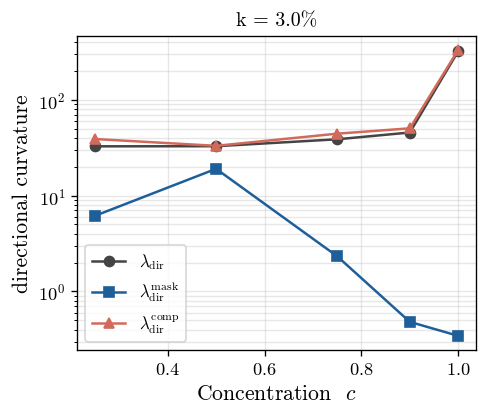


Phase 4 summary:
  k=3.0%: λ_dir grew +885% from c=25% to c=100%;  λ_mask -94%;  λ_comp +753%


In [9]:
# ── Phase 4 — Plot λ_dir, λ_dir^mask, λ_dir^comp vs c ────────────────
import pickle

_LATEX_RC = {
    'font.family'       : 'serif',
    'font.serif'        : ['cmr10', 'DejaVu Serif'],
    'mathtext.fontset'  : 'cm',
    'axes.formatter.use_mathtext': True,
    'axes.unicode_minus': False,
    'font.size'         : 11,
}

# Group by sparsity → one subplot per k_frac.
ks = sorted(df["k_frac"].unique())
ncols = max(1, len(ks))

with plt.rc_context(_LATEX_RC):
    fig, axes = plt.subplots(1, ncols, figsize=(4.2 * ncols, 3.6), squeeze=False)
    for j, k in enumerate(ks):
        ax = axes[0, j]
        sub = df[df["k_frac"] == k].sort_values("burst")
        cs  = sub["burst"].values
        ax.plot(cs, sub["lam_dir"].values,  marker="o", lw=1.5,
                label=r"$\lambda_{\mathrm{dir}}$",        color="#444444")
        ax.plot(cs, sub["lam_mask"].values, marker="s", lw=1.5,
                label=r"$\lambda_{\mathrm{dir}}^{\mathrm{mask}}$", color="#1f5f99")
        ax.plot(cs, sub["lam_comp"].values, marker="^", lw=1.5,
                label=r"$\lambda_{\mathrm{dir}}^{\mathrm{comp}}$", color="#d16a5a")
        ax.set_yscale("log")
        ax.set_xlabel(r"Concentration  $c$", fontsize=13)
        ax.set_ylabel(r"directional curvature", fontsize=13)
        ax.set_title(f"k = {k:.1%}", fontsize=12)
        ax.grid(True, alpha=0.3, which="both")
        ax.legend(fontsize=10, loc="best")

    fig.tight_layout()

    fig_path = OUT_DIR / OUT_NAME
    fig.savefig(fig_path.with_suffix(".pdf"), bbox_inches="tight")
    fig.savefig(fig_path.with_suffix(".png"), bbox_inches="tight", dpi=200)
    with open(fig_path.with_suffix(".pkl"), "wb") as f:
        pickle.dump({
            "df": df.to_dict(orient="records"),
            "bursts": BURSTS_TO_RUN,
            "sparsity_levels": SPARSITY_LEVELS,
            "mask_steps": MASK_STEPS,
            "fd_eps": FD_EPS,
        }, f)
    print(f"saved: {fig_path.with_suffix('.pdf')}")
    print(f"       {fig_path.with_suffix('.png')}")
    print(f"       {fig_path.with_suffix('.pkl')}")
    plt.show()

# ── Quick summary string ─────────────────────────────────────────────
def _pct_change(y0, y1):
    return (y1 - y0) / (abs(y0) + 1e-30)

print("\nPhase 4 summary:")
for k in ks:
    sub = df[df["k_frac"] == k].sort_values("burst")
    if len(sub) < 2:
        continue
    g_full = _pct_change(sub["lam_dir"].iloc[0],  sub["lam_dir"].iloc[-1])
    g_mask = _pct_change(sub["lam_mask"].iloc[0], sub["lam_mask"].iloc[-1])
    g_comp = _pct_change(sub["lam_comp"].iloc[0], sub["lam_comp"].iloc[-1])
    print(f"  k={k:.1%}: λ_dir grew {g_full:+.0%} from c={sub['burst'].iloc[0]:.0%} "
          f"to c={sub['burst'].iloc[-1]:.0%};  "
          f"λ_mask {g_mask:+.0%};  λ_comp {g_comp:+.0%}")
